### Домашнє завдання: Кластеризація в Аналізі Персоналій Клієнтів

#### Контекст
В цьому ДЗ ми скористаємось алгоритмами кластеризації для задачі аналізу портретів клієнтів (Customer Personality Analysis).

Customer Personality Analysis - це аналіз різних сегментів клієнтів компанії. Цей аналіз дозволяє бізнесу краще розуміти своїх клієнтів і полегшує процес адаптації продуктів під конкретні потреби, поведінку та інтереси різних типів клієнтів.

Аналіз портретів клієнтів допомагає бізнесу змінювати свій продукт на основі цільової аудиторії, розділеної на різні сегменти. Наприклад, замість того, щоб витрачати гроші на маркетинг нового продукту для всіх клієнтів у базі даних компанії, бізнес може проаналізувати, який сегмент клієнтів найімовірніше придбає продукт, і потім зосередити маркетингові зусилля лише на цьому сегменті.

#### Завдання
На основі наданих даних в файлі `marketing_campaign.csv` потрібно виконати кластеризацію, щоб виявити сегменти клієнтів.

#### Вхідні дані
Вам надано набір даних з такими атрибутами:

**Характеристики користувачів:**
- `ID`: Унікальний ідентифікатор клієнта
- `Year_Birth`: Рік народження клієнта
- `Education`: Рівень освіти клієнта
- `Marital_Status`: Сімейний стан клієнта
- `Income`: Річний дохід домогосподарства клієнта
- `Kidhome`: Кількість дітей у домогосподарстві клієнта
- `Teenhome`: Кількість підлітків у домогосподарстві клієнта
- `Dt_Customer`: Дата реєстрації клієнта у компанії
- `Recency`: Кількість днів з моменту останньої покупки клієнта
- `Complain`: 1, якщо клієнт скаржився за останні 2 роки, 0 - якщо ні

**Продукти:**
- `MntWines`: Сума, витрачена на вино за останні 2 роки
- `MntFruits`: Сума, витрачена на фрукти за останні 2 роки
- `MntMeatProducts`: Сума, витрачена на м'ясні продукти за останні 2 роки
- `MntFishProducts`: Сума, витрачена на рибні продукти за останні 2 роки
- `MntSweetProducts`: Сума, витрачена на солодощі за останні 2 роки
- `MntGoldProds`: Сума, витрачена на золото за останні 2 роки

**Акції:**
- `NumDealsPurchases`: Кількість покупок, зроблених з використанням знижок
- `AcceptedCmp1`: 1, якщо клієнт прийняв пропозицію у першій кампанії, 0 - якщо ні
- `AcceptedCmp2`: 1, якщо клієнт прийняв пропозицію у другій кампанії, 0 - якщо ні
- `AcceptedCmp3`: 1, якщо клієнт прийняв пропозицію у третій кампанії, 0 - якщо ні
- `AcceptedCmp4`: 1, якщо клієнт прийняв пропозицію у четвертій кампанії, 0 - якщо ні
- `AcceptedCmp5`: 1, якщо клієнт прийняв пропозицію у п'ятій кампанії, 0 - якщо ні
- `Response`: 1, якщо клієнт прийняв пропозицію в останній кампанії, 0 - якщо ні

**Взаємодія з компанією:**
- `NumWebPurchases`: Кількість покупок, зроблених через вебсайт компанії
- `NumCatalogPurchases`: Кількість покупок, зроблених за каталогом
- `NumStorePurchases`: Кількість покупок, зроблених безпосередньо у магазинах
- `NumWebVisitsMonth`: Кількість відвідувань вебсайту компанії за останній місяць


**Завдання 1**. Завантажте дані з `marketing_campaign.csv` в Pandas dataframe і виведіть основну інформацію про дані: скільки всього рядків і колонок, які типи даних мають колонки, скільки пропущених значень.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn import metrics
from sklearn.cluster import KMeans, DBSCAN
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
import plotly.express as px

In [2]:
import warnings
warnings.filterwarnings('ignore')

In [3]:
raw_df = pd.read_csv('marketing_campaign.csv', sep="\t")
raw_df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,5,0,0,0,0,0,0,3,11,0


In [4]:
raw_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 29 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   2240 non-null   int64  
 1   Year_Birth           2240 non-null   int64  
 2   Education            2240 non-null   object 
 3   Marital_Status       2240 non-null   object 
 4   Income               2216 non-null   float64
 5   Kidhome              2240 non-null   int64  
 6   Teenhome             2240 non-null   int64  
 7   Dt_Customer          2240 non-null   object 
 8   Recency              2240 non-null   int64  
 9   MntWines             2240 non-null   int64  
 10  MntFruits            2240 non-null   int64  
 11  MntMeatProducts      2240 non-null   int64  
 12  MntFishProducts      2240 non-null   int64  
 13  MntSweetProducts     2240 non-null   int64  
 14  MntGoldProds         2240 non-null   int64  
 15  NumDealsPurchases    2240 non-null   i

In [5]:
print(f"Розмір датасету: {raw_df.shape[0]} рядків, {raw_df.shape[1]} колонок\n")
print(f"Пропущені значення:")
print(raw_df.isnull().sum()[raw_df.isnull().sum() > 0])
print(f"\nКількість пропущених: {raw_df.isnull().sum().sum()}")

Розмір датасету: 2240 рядків, 29 колонок

Пропущені значення:
Income    24
dtype: int64

Кількість пропущених: 24


**Завдання 2.** Заповніть пропущені значення з врахуванням того завдання (кластеризація), яке ми виконуємо. Поясніть свій вибір заповнення пропущених значень.

In [6]:
raw_df["Income"].describe()

count      2216.000000
mean      52247.251354
std       25173.076661
min        1730.000000
25%       35303.000000
50%       51381.500000
75%       68522.000000
max      666666.000000
Name: Income, dtype: float64

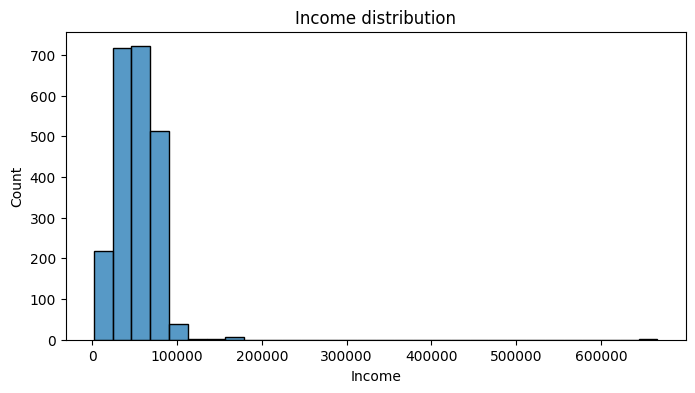

In [7]:
plt.figure(figsize=(8, 4))
sns.histplot(raw_df["Income"], bins=30)
plt.title("Income distribution")
plt.show()

Оскільки задача передбачає кластеризацію, важливо виконати імпутацію таким чином, щоб не спотворити структуру даних і не створити штучні сегменти клієнтів.

Income має правосторонній розподіл (є дуже великі значення), тому тут медіана буде кращою для заповнення пустих значень. Також для кластеризації важливо не спотворити розподіл — медіана стійкіша до викидів, ніж середнє. В той же час видаляти рядки небажано — це 1% даних, але кожен клієнт може бути цінним для аналізу сегментів.

In [8]:
raw_df.groupby("Education")["Income"].median().sort_values()

Education
Basic         20744.0
2n Cycle      46805.0
Master        50943.0
Graduation    52028.5
PhD           55212.0
Name: Income, dtype: float64

In [9]:
df = raw_df.copy()

In [10]:
# Заповнимо Income медіаною в межах Education: це менш чутливо до викидів і зберігає приблизний соціально-економічний контекст клієнта
df["Income"] = df["Income"].fillna(df.groupby("Education")["Income"].transform("median"))
df["Income"] = df["Income"].fillna(df["Income"].median())

In [11]:
df.isna().sum()

ID                     0
Year_Birth             0
Education              0
Marital_Status         0
Income                 0
Kidhome                0
Teenhome               0
Dt_Customer            0
Recency                0
MntWines               0
MntFruits              0
MntMeatProducts        0
MntFishProducts        0
MntSweetProducts       0
MntGoldProds           0
NumDealsPurchases      0
NumWebPurchases        0
NumCatalogPurchases    0
NumStorePurchases      0
NumWebVisitsMonth      0
AcceptedCmp3           0
AcceptedCmp4           0
AcceptedCmp5           0
AcceptedCmp1           0
AcceptedCmp2           0
Complain               0
Z_CostContact          0
Z_Revenue              0
Response               0
dtype: int64

**Завдання 3.** У нас є декілька колонок з категоріальними значеннями та одна колонка з датою. Як би ви обробили ці колонки для того, аби передати їх в алгоритм кластеризації?

Реалізуйте обробку категоріальних колонок і колонки з датою та перетворіть їх на ознаки, корисні для кластеризації з вашого погляду.

In [12]:
cat_cols = df.select_dtypes(include=["object"]).columns.tolist()
cat_cols

['Education', 'Marital_Status', 'Dt_Customer']

In [13]:
print(f"Education: {df['Education'].unique()}")
print(f"Marital_Status: {df['Marital_Status'].unique()}")

Education: ['Graduation' 'PhD' 'Master' 'Basic' '2n Cycle']
Marital_Status: ['Single' 'Together' 'Married' 'Divorced' 'Widow' 'Alone' 'Absurd' 'YOLO']


In [14]:
# Education: є природній порядок рівнів освіти, тому використаємо ordinal encoding
education_map = {'Basic': 0, '2n Cycle': 1, 'Graduation': 2, 'Master': 3, 'PhD': 4}
df['Education_Ord'] = df['Education'].map(education_map)

In [15]:
# Marital_Status: немає природного порядку, тому зробимо one-hot encoding
df['Marital_Group'] = df['Marital_Status'].replace({
    'Married': 'Couple',
    'Together': 'Couple',
    'Single': 'Single',
    'Divorced': 'Single',
    'Widow': 'Single',
    'Alone': 'Single',
    'Absurd': 'Other',
    'YOLO': 'Other'
})

In [16]:
marital_dummies = pd.get_dummies(df['Marital_Group'], prefix='Marital')
df = pd.concat([df, marital_dummies], axis=1)

In [17]:
#  Dt_Customer: перетворимо дату реєстрації на кількість днів до останньої дати в датасеті — це числова ознака, що відображає давність / стаж клієнта
df['Dt_Customer'] = pd.to_datetime(df['Dt_Customer'], format='%d-%m-%Y')
df['Customer_Days'] = (df['Dt_Customer'].max() - df['Dt_Customer']).dt.days

In [18]:
# Видалимо оригінальні категоріальні колонки та непотрібні:
# Z_CostContact і Z_Revenue — константи, не корисні для кластеризації
# ID — ідентифікатор, не ознака

cols_to_drop = ['ID', 'Education', 'Marital_Status', 'Marital_Group', 'Dt_Customer',
                'Z_CostContact', 'Z_Revenue']
df_clean = df.drop(columns=cols_to_drop)

bool_cols = df_clean.select_dtypes(include='bool').columns
df_clean[bool_cols] = df_clean[bool_cols].astype(int)

df_clean.head()

,Year_Birth,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,...,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Response,Education_Ord,Marital_Couple,Marital_Other,Marital_Single,Customer_Days
0,1957,58138.0,0,0,58,635,88,546,172,88,...,0,0,0,0,1,2,0,0,1,663
1,1954,46344.0,1,1,38,11,1,6,2,1,...,0,0,0,0,0,2,0,0,1,113
2,1965,71613.0,0,0,26,426,49,127,111,21,...,0,0,0,0,0,2,1,0,0,312
3,1984,26646.0,1,0,26,11,4,20,10,3,...,0,0,0,0,0,2,1,0,0,139
4,1981,58293.0,1,0,94,173,43,118,46,27,...,0,0,0,0,0,4,1,0,0,161


In [19]:
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 28 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Year_Birth           2240 non-null   int64  
 1   Income               2240 non-null   float64
 2   Kidhome              2240 non-null   int64  
 3   Teenhome             2240 non-null   int64  
 4   Recency              2240 non-null   int64  
 5   MntWines             2240 non-null   int64  
 6   MntFruits            2240 non-null   int64  
 7   MntMeatProducts      2240 non-null   int64  
 8   MntFishProducts      2240 non-null   int64  
 9   MntSweetProducts     2240 non-null   int64  
 10  MntGoldProds         2240 non-null   int64  
 11  NumDealsPurchases    2240 non-null   int64  
 12  NumWebPurchases      2240 non-null   int64  
 13  NumCatalogPurchases  2240 non-null   int64  
 14  NumStorePurchases    2240 non-null   int64  
 15  NumWebVisitsMonth    2240 non-null   i

In [20]:
df_clean.isna().sum().sum()

np.int64(0)

**Завдання 4**.
1. Запишіть в змінну X ті дані, які будете кластеризувати.
2. Побудуйте кластеризацію з KMeans на 3 кластери.
3. Обчисліть метрику силуету для цієї кластеризації.

In [21]:
X = df_clean.copy()

In [22]:
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X)

In [23]:
score = silhouette_score(X, clusters)
print(f"Silhouette score: {score:.4f}")
print(f"Розподіл по кластерах:")
print(pd.Series(clusters).value_counts().sort_index())

Silhouette score: 0.5988
Розподіл по кластерах:
0    1162
1       1
2    1077
Name: count, dtype: int64


KMeans було застосовано до немасштабованих даних з кількістю кластерів K=3. Отримано Silhouette score = 0.5988. На перший погляд значення метрики є досить непоганим, однак розподіл об'єктів між кластерами показує проблему: один із кластерів містить лише 1 клієнта. Це свідчить про те, що без масштабування KMeans може бути дуже чутливим до ознак з великими значеннями та викидів. Тому отримана кластеризація не є достатньо надійною.

**Завдання 5.** Візуалізуйте знайдені кластери разом з наявними даними та проаналізуйте кластери. У нас ознак більше, ніж 2 або 3, тож, тут треба подумати, які саме ознаки варто використати для візуалізації аби вони були інформативними. Рекомендую точно звернути увагу на харакетиристики про дохід користувачів і те, як вони взаємодять з магазинок (кількість покупок і тд).

Для візуалізації зручно може бути використати `plotly.express.scatter_3d` для 3D графіку розсіювання, але тут можна скористатись будь-яким зрозумілим і зручним для вас методом візуалізації. Опишіть свої спостереження, чи кластери мають сенс?

In [24]:
df_viz = df_clean.copy()
df_viz["cluster"] = clusters

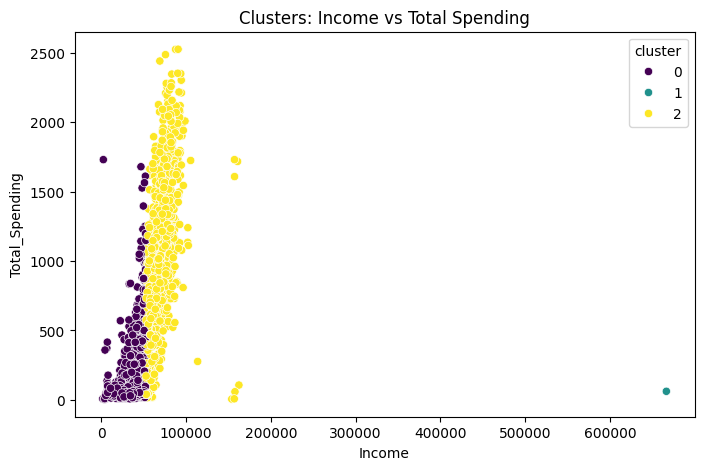

In [25]:
# Income vs Total spending
df_viz["Total_Spending"] = (
    df_viz["MntWines"] +
    df_viz["MntFruits"] +
    df_viz["MntMeatProducts"] +
    df_viz["MntFishProducts"] +
    df_viz["MntSweetProducts"] +
    df_viz["MntGoldProds"]
)

plt.figure(figsize=(8, 5))
sns.scatterplot(
    data=df_viz,
    x="Income",
    y="Total_Spending",
    hue="cluster",
    palette="viridis"
)
plt.title("Clusters: Income vs Total Spending")
plt.show()

In [26]:
fig = px.scatter_3d(
    df_viz,
    x='Income',
    y='Total_Spending',
    z='NumStorePurchases',
    color='cluster',
    title='3D: Income vs Total Spending vs Store Purchases'
)
fig.show()

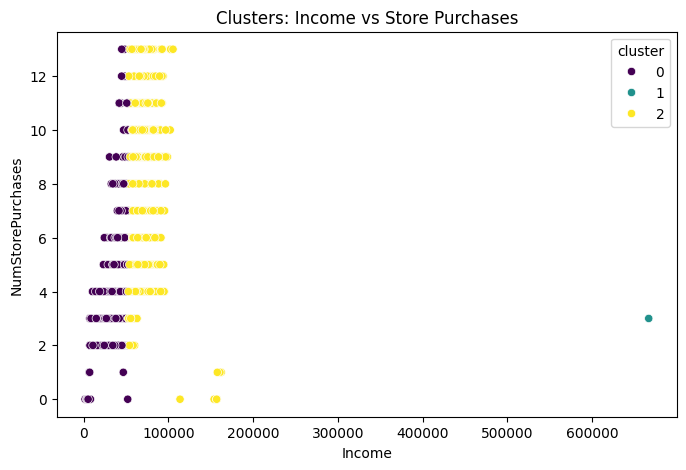

In [27]:
# Income vs Store purchases
plt.figure(figsize=(8, 5))
sns.scatterplot(
    data=df_viz,
    x="Income",
    y="NumStorePurchases",
    hue="cluster",
    palette="viridis"
)
plt.title("Clusters: Income vs Store Purchases")
plt.show()

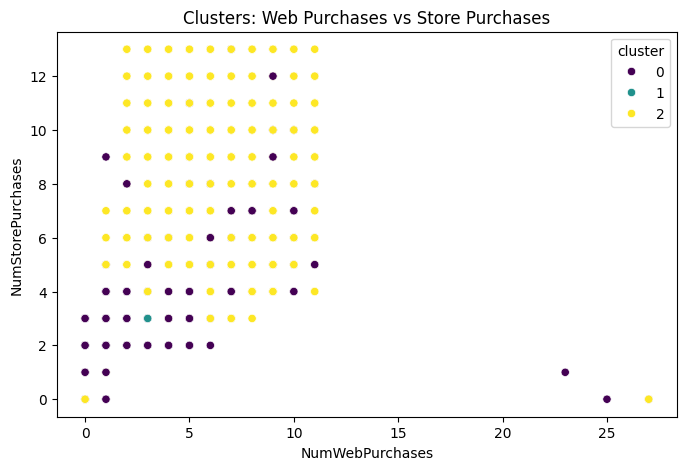

In [28]:
# Web purchases vs Store purchases
plt.figure(figsize=(8, 5))
sns.scatterplot(
    data=df_viz,
    x="NumWebPurchases",
    y="NumStorePurchases",
    hue="cluster",
    palette="viridis"
)
plt.title("Clusters: Web Purchases vs Store Purchases")
plt.show()

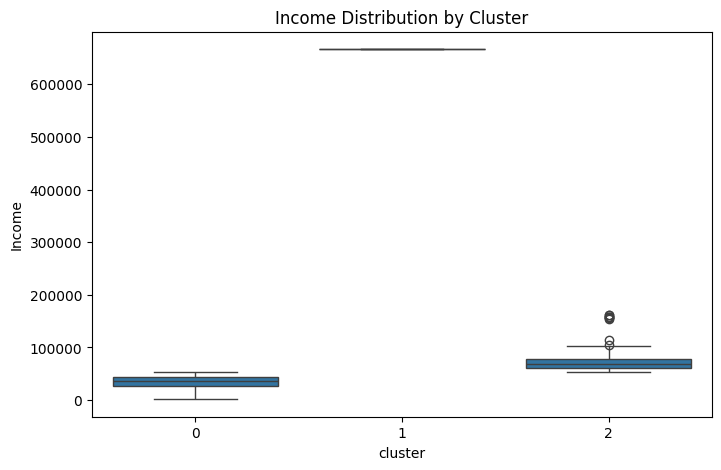

In [29]:
# Boxplot по доходу
plt.figure(figsize=(8, 5))
sns.boxplot(
    data=df_viz,
    x="cluster",
    y="Income"
)
plt.title("Income Distribution by Cluster")
plt.show()

In [30]:
cluster_profile = df_viz.groupby("cluster")[
    [
        "Income",
        "Total_Spending",
        "MntWines",
        "MntMeatProducts",
        "NumWebPurchases",
        "NumStorePurchases",
        "Recency",
        "Customer_Days"
    ]
].mean().round(2)

cluster_profile

,Income,Total_Spending,MntWines,MntMeatProducts,NumWebPurchases,NumStorePurchases,Recency,Customer_Days
cluster,,,,,,,,
0,34936.61,173.59,83.23,39.37,2.79,3.69,49.33,353.31
1,666666.00,62.00,9.00,18.00,3.00,3.00,23.00,392.00
2,70343.92,1072.62,542.33,304.74,5.49,8.06,48.90,353.84


Кластеризація виявила 3 групи клієнтів, однак один із кластерів містить лише одного клієнта з аномально високим доходом (~666k). Це свідчить про наявність викиду в даних, який суттєво вплинув на результат KMeans.

Основне розділення клієнтів відбувається між двома сегментами:       
- Кластер 0 — клієнти з низьким доходом та низькою активністю (мало витрат і покупок)
- Кластер 2 — клієнти з вищим доходом та високою активністю (значні витрати)

Таким чином, кластеризація частково має сенс, але через відсутність масштабування та обробки викидів результат не є повністю надійним.

**Завдання 6**. Масштабуйте дані (StandardScaler/MinMaxScaler) і побудуйте знову кластеризацію KMeans на 3 кластери і обчисліть метрику силуету. Опишіть порівняння з експериментом без масштабування значень.

In [31]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [32]:
kmeans_scaled = KMeans(n_clusters=3, random_state=42)
clusters_scaled = kmeans_scaled.fit_predict(X_scaled)

score_scaled = silhouette_score(X_scaled, clusters_scaled)

In [33]:
print(f"Silhouette score (not scaled): {score:.4f}")
print(f"Розподіл по кластерах (not scaled):")
print(pd.Series(clusters).value_counts().sort_index())

print(f"\nSilhouette score (scaled): {score_scaled:.4f}")
print(f"Розподіл по кластерах (scaled):")
print(pd.Series(clusters_scaled).value_counts().sort_index())

Silhouette score (not scaled): 0.5988
Розподіл по кластерах (not scaled):
0    1162
1       1
2    1077
Name: count, dtype: int64

Silhouette score (scaled): 0.1020
Розподіл по кластерах (scaled):
0    501
1    818
2    921
Name: count, dtype: int64


До масштабування silhouette score становив 0.5988, що виглядає як хороший результат. Проте аналіз показав, що один із кластерів містив лише одного клієнта з аномально високим доходом (~666k). Таким чином, високе значення метрики було досягнуто за рахунок викиду, а не через наявність реальної кластерної структури в даних.

Після масштабування silhouette score знизився до 0.1020. Це пов’язано з тим, що всі ознаки були приведені до одного масштабу, і алгоритм почав враховувати не лише дохід, а й поведінкові характеристики (витрати, покупки). У результаті кластери стали більш збалансованими (501, 818, 921), але менш чітко розділеними. Зниження silhouette score свідчить про те, що в даних немає вираженої кластерної структури, а не про погіршення моделі.

Таким чином:
- без масштабування результат є оманливим через домінування ознаки Income
- після масштабування кластеризація є більш коректною, але показує, що сегментація клієнтів не є чітко вираженою

**Завдання 7.** З візуалізацій на попередньому кроці ви могли побачити якісь викиди в даних. Опрацюйте викиди (можна видалити ці рядки або придумати інший спосіб).

In [34]:
df_clean["Total_Spending"] = (
    df_clean["MntWines"] +
    df_clean["MntFruits"] +
    df_clean["MntMeatProducts"] +
    df_clean["MntFishProducts"] +
    df_clean["MntSweetProducts"] +
    df_clean["MntGoldProds"]
)

cols_to_check = [
    "Income",
    "Total_Spending",
    "MntWines",
    "MntMeatProducts",
    "MntFishProducts",
    "MntSweetProducts",
    "MntGoldProds"
]

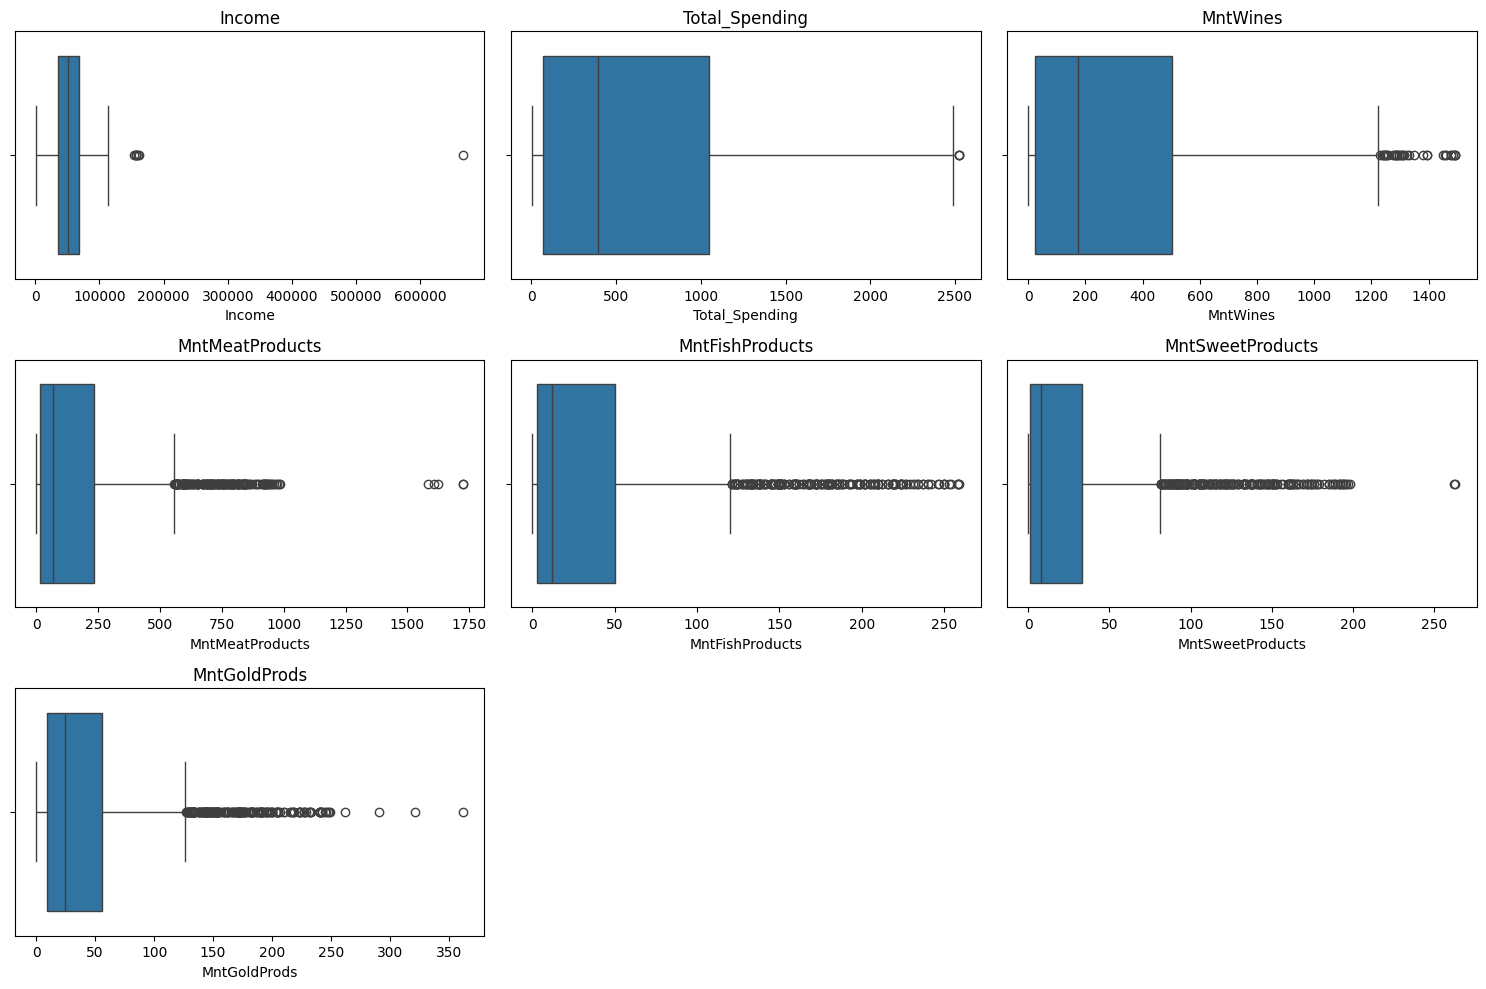

In [35]:
plt.figure(figsize=(15, 10))

for i, col in enumerate(cols_to_check, 1):
    plt.subplot(3, 3, i)
    sns.boxplot(x=df_clean[col])
    plt.title(col)

plt.tight_layout()
plt.show()

In [36]:
Q1 = df_clean["Income"].quantile(0.25)
Q3 = df_clean["Income"].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

df_no_outliers = df_clean[
    (df_clean["Income"] >= lower_bound) &
    (df_clean["Income"] <= upper_bound)
].copy()

In [37]:
# Додатково обмежимо крайні значення у spending-ознаках через clipping - це не видаляє клієнтів, а лише зменшує вплив дуже великих значень на KMeans

cols_to_clip = [
    "Total_Spending",
    "MntWines",
    "MntMeatProducts",
    "MntFishProducts",
    "MntSweetProducts",
    "MntGoldProds"
]

df_no_outliers_clipped = df_no_outliers.copy()

for col in cols_to_clip:
    Q1 = df_no_outliers_clipped[col].quantile(0.25)
    Q3 = df_no_outliers_clipped[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    df_no_outliers_clipped[col] = df_no_outliers_clipped[col].clip(lower=lower, upper=upper)

In [38]:
# Використовуємо лише релевантні ознаки (дохід, витрати, покупки), щоб уникнути шуму, дублювання інформації та покращити якість кластеризації

features = [
    "Income",
    "Total_Spending",
    "MntWines",
    "MntMeatProducts",
    "MntFishProducts",
    "MntSweetProducts",
    "MntGoldProds",
    "NumWebPurchases",
    "NumStorePurchases"
]

scaler = StandardScaler()
X_no_out = scaler.fit_transform(df_no_outliers_clipped[features])

kmeans_no_out = KMeans(n_clusters=3, random_state=42)
clusters_no_out = kmeans_no_out.fit_predict(X_no_out)

score_no_out = silhouette_score(X_no_out, clusters_no_out)

print(f"Silhouette score: {score_no_out:.4f}")
print(pd.Series(clusters_no_out).value_counts().sort_index())

Silhouette score: 0.3921
0     597
1     582
2    1053
Name: count, dtype: int64


Для обробки викидів було використано комбінований підхід: екстремальні значення в Income видалено за правилом IQR, оскільки вони виглядали аномальними та суттєво впливали на KMeans, тоді як для spending-ознак застосовано clipping — обмеження крайніх значень без видалення рядків, адже високі витрати можуть бути реальною поведінкою клієнтів.

Після обробки дані були масштабовані за допомогою StandardScaler і повторно кластеризовані методом KMeans (K=3). Отриманий silhouette score становить 0.3921, що значно краще порівняно з 0.1020 на даних з викидами. Це покращення пояснюється як зменшенням впливу аномальних значень, так і більш релевантним вибором ознак — замість усіх 28 було використано 9 ключових (дохід, витрати та активність покупок), що дозволило зменшити шум у даних.

У результаті кластери стали більш чіткими та інтерпретованими, а розподіл клієнтів — більш збалансованим (597, 582 і 1053 клієнти).

***Створимо візуалізацію кластерів відмасштабованих даних з викидами та без:***

In [39]:
df_scaled_viz = df_clean.copy()
df_scaled_viz['cluster'] = clusters_scaled

df_no_out_viz = df_no_outliers_clipped.copy()
df_no_out_viz["cluster"] = clusters_no_out

# Total Spending
for df_ in [df_scaled_viz, df_no_out_viz]:
    df_['Total_Spending'] = (
        df_['MntWines'] +
        df_['MntFruits'] +
        df_['MntMeatProducts'] +
        df_['MntFishProducts'] +
        df_['MntSweetProducts'] +
        df_['MntGoldProds']
    )

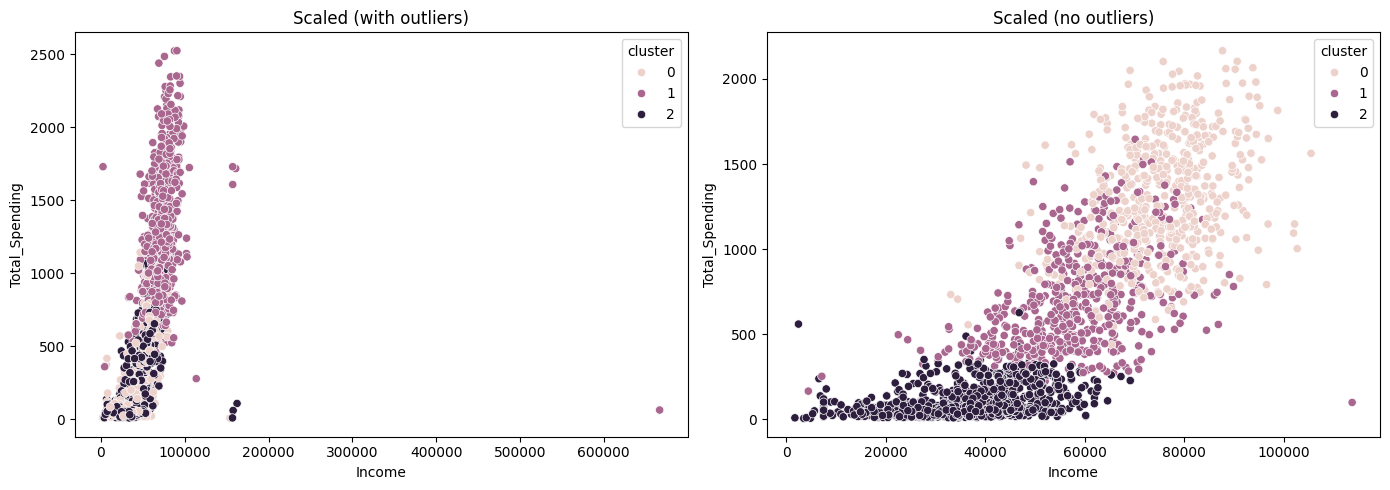

In [40]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.scatterplot(
    data=df_scaled_viz,
    x='Income',
    y='Total_Spending',
    hue='cluster',
    ax=axes[0]
)
axes[0].set_title('Scaled (with outliers)')

sns.scatterplot(
    data=df_no_out_viz,
    x='Income',
    y='Total_Spending',
    hue='cluster',
    ax=axes[1]
)
axes[1].set_title('Scaled (no outliers)')

plt.tight_layout()
plt.show()

In [41]:
fig = px.scatter_3d(
    df_no_out_viz,
    x='Income',
    y='Total_Spending',
    z='NumStorePurchases',
    color='cluster',
    title='3D (no outliers)'
)
fig.show()

Висновки по візуалізаціям:

- Викиди сильно спотворюють графіки: без їх обробки основна маса даних “стиснута”, і кластери погано видно.  
- Після видалення/обмеження викидів структура стає чіткішою — кластери добре розділяються.  
- Видно логічні сегменти клієнтів: низькі, середні та високі витрати/доходи.  
- Спостерігається позитивна залежність між Income і Total_Spending.  
- 3D-візуалізація показує, що кластери також відрізняються за активністю покупок.

Отже, обробка викидів значно покращила якість і інтерпретованість кластеризації.

In [42]:
cluster_profile = df_no_out_viz.groupby("cluster")[features].mean()
cluster_profile

,Income,Total_Spending,MntWines,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumWebPurchases,NumStorePurchases
cluster,,,,,,,,,
0,75017.652429,1295.174832,625.103853,393.177764,83.638191,57.128141,68.646147,5.497487,8.601340
1,58202.159794,694.588703,441.265464,130.517612,25.554124,18.153780,55.891538,6.254296,7.579038
2,34749.649573,98.863604,44.226021,23.960351,6.743590,4.816714,14.284069,2.112061,3.245964


In [43]:
scaler = StandardScaler()
cluster_profile_scaled = pd.DataFrame(
    scaler.fit_transform(cluster_profile),
    columns=cluster_profile.columns,
    index=cluster_profile.index
)

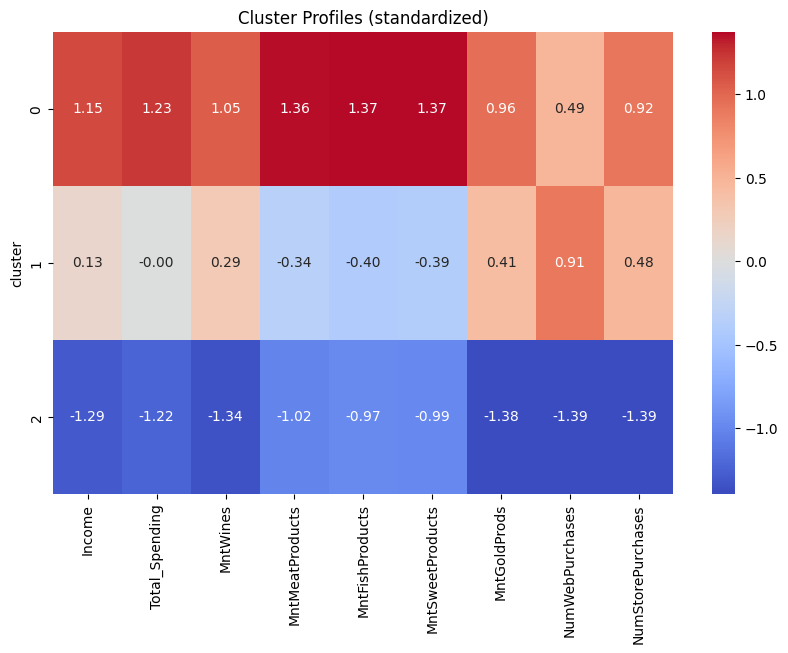

In [44]:
plt.figure(figsize=(10, 6))

sns.heatmap(
    cluster_profile_scaled,
    annot=True,
    cmap="coolwarm",
    center=0,
    fmt=".2f"
)

plt.title("Cluster Profiles (standardized)")
plt.show()

Було побудовано профілі кластерів на основі середніх значень ознак. Для кращої інтерпретації всі значення були стандартизовані.
На основі heatmap кластерних профілів було 3 чіткі сегменти клієнтів:

- Кластер 0 — клієнти з високим доходом і витратами. Вони активно купують усі категорії товарів і мають найвищі значення по більшості ознак. Це преміум сегмент клієнтів.

- Кластер 1 — клієнти із середнім доходом і витратами, але з високою активністю покупок, особливо онлайн. Вони частіше здійснюють покупки через веб, ніж інші групи. Це активні digital-клієнти.

- Кластер 2 — клієнти з низьким доходом і низькою активністю. Вони рідко купують і мають найнижчі значення по всіх ознаках. Це малозначущий сегмент.

Ці результати показують, що клієнти відрізняються не лише рівнем доходу, але й поведінкою покупок, зокрема каналами взаємодії (онлайн vs офлайн).

**Завдання 8.** Виконайте Elbow method для пошуку оптимальної кількості кластерів та натренуйте KMeans з тою кількістю кластерів, яку Elbow method показав як оптимальну. Обчисліть метрику силуету. Візуалізуйте кластери. З яким набором даних (масштабованим чи ні) тут працювати - ваш вибір, можна зробити експеримент з обома.

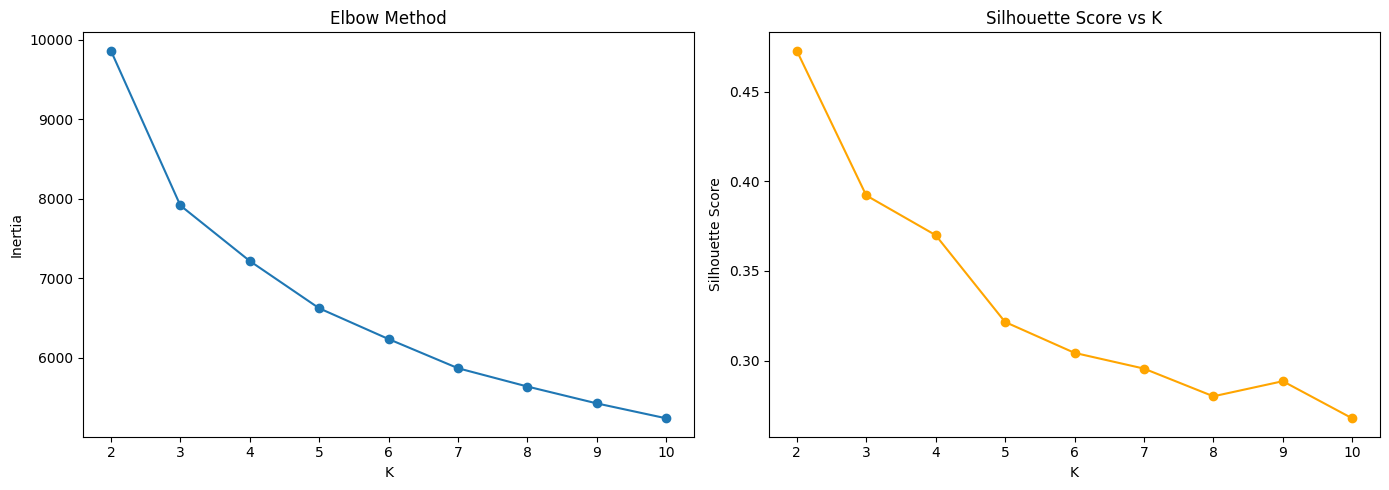


Silhouette scores:
K=2: 0.4728
K=3: 0.3921
K=4: 0.3699
K=5: 0.3215
K=6: 0.3043
K=7: 0.2956
K=8: 0.2801
K=9: 0.2885
K=10: 0.2678


In [45]:
# Використовуємо масштабовані дані без викидів (X_no_out) з тим самим набором ознак

K_range = range(2, 11)
inertias = []
sil_scores = []

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_no_out)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(X_no_out, labels))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(K_range, inertias, marker='o')
axes[0].set_xlabel('K')
axes[0].set_ylabel('Inertia')
axes[0].set_title('Elbow Method')
axes[0].set_xticks(list(K_range))

axes[1].plot(K_range, sil_scores, marker='o', color='orange')
axes[1].set_xlabel('K')
axes[1].set_ylabel('Silhouette Score')
axes[1].set_title('Silhouette Score vs K')
axes[1].set_xticks(list(K_range))

plt.tight_layout()
plt.show()

print("\nSilhouette scores:")
for k, s in zip(K_range, sil_scores):
    print(f"K={k}: {s:.4f}")

In [59]:
# --- K=2 ---
kmeans_2 = KMeans(n_clusters=2, random_state=42, n_init=10)
clusters_2 = kmeans_2.fit_predict(X_no_out)

score_2 = silhouette_score(X_no_out, clusters_2)

print(f"K=2 silhouette: {score_2:.4f}")
print("K=2 distribution:")
print(pd.Series(clusters_2).value_counts().sort_index())


# --- K=3 ---
kmeans_3 = KMeans(n_clusters=3, random_state=42, n_init=10)
clusters_3 = kmeans_3.fit_predict(X_no_out)

score_3 = silhouette_score(X_no_out, clusters_3)

print(f"\nK=3 silhouette: {score_3:.4f}")
print("K=3 distribution:")
print(pd.Series(clusters_3).value_counts().sort_index())

K=2 silhouette: 0.4728
K=2 distribution:
0     952
1    1280
Name: count, dtype: int64

K=3 silhouette: 0.3921
K=3 distribution:
0    1054
1     597
2     581
Name: count, dtype: int64


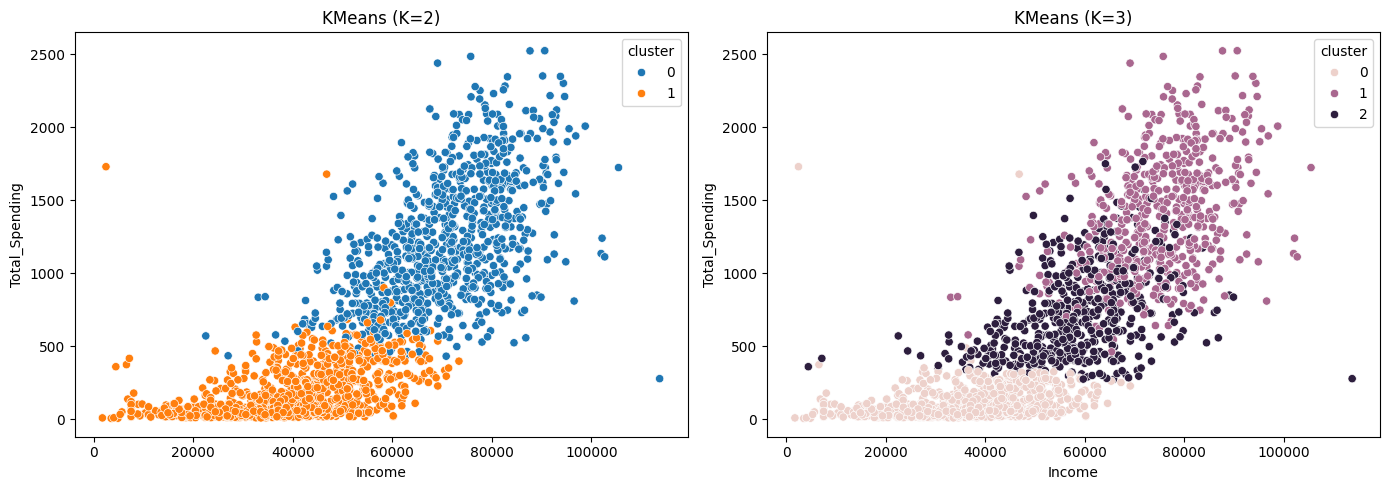

In [61]:
# --- Візуалізація ---
df_viz = df_no_outliers.copy()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# K=2
df_viz["cluster"] = clusters_2
sns.scatterplot(
    data=df_viz,
    x="Income",
    y="Total_Spending",
    hue="cluster",
    ax=axes[0]
)
axes[0].set_title("KMeans (K=2)")

# K=3
df_viz["cluster"] = clusters_3
sns.scatterplot(
    data=df_viz,
    x="Income",
    y="Total_Spending",
    hue="cluster",
    ax=axes[1]
)
axes[1].set_title("KMeans (K=3)")

plt.tight_layout()
plt.show()

Elbow method підтвердив, що K=3 є оптимальною кількістю кластерів: на графіку видно лікоть при K=3. Silhouette score при K=2 є найвищим, але K=2 дає занадто грубу сегментацію. K=3 забезпечує баланс між детальністю сегментації та якістю розділення.

Silhouette score для K=3 становить 0.3921 — це помірне значення, яке вказує на наявність кластерної структури, хоча і з деяким перекриттям між сегментами. Кластери відповідають тим самим трьом сегментам клієнтів, що були виявлені раніше: преміум-клієнти (високий дохід і витрати), активні digital-клієнти (середній рівень) та малоактивні клієнти (низький дохід і витрати).

**Завдання 9.** Використовуючи методи `scipy` `dendrogram, linkage, fcluster`
1. Побудуйте ієрархічну агломеративну кластеризацію з `single linkage` на даних невідмасштабованих, але з прибраним викидом.
2. Візуалізуйте дендрограму. При візуалізації обовʼязково задайте параметр `truncate_mode='lastp'` - це обріже дендрограму, без цього вона буде завелика, бо у нас тут даних суттєво більше, ніж в лекції.
3. Проаналізуйте дендрограму та побудуйте варіанти плоских кластеризацій з `fcluster` на 2 і 3 кластери. Візуалізуйте результати кожної з цих кластеризацій та зробіть висновок. Чи вважаєте ви якусь з цих кластеризацій вдалою? Що спостерігаєте з цих кластеризацій?
4. Порахуйте мерику силуету для цього методу кластеризації.

In [ ]:
df_no_outliers.head()

,Year_Birth,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,...,AcceptedCmp1,AcceptedCmp2,Complain,Response,Education_Ord,Marital_Couple,Marital_Other,Marital_Single,Customer_Days,Total_Spending
0,1957,58138.0,0,0,58,635.0,88,546.0,120.5,83.5,...,0,0,0,1,2,0,0,1,663,1617.0
1,1954,46344.0,1,1,38,11.0,1,6.0,2.0,1.0,...,0,0,0,0,2,0,0,1,113,27.0
2,1965,71613.0,0,0,26,426.0,49,127.0,111.0,21.0,...,0,0,0,0,2,1,0,0,312,776.0
3,1984,26646.0,1,0,26,11.0,4,20.0,10.0,3.0,...,0,0,0,0,2,1,0,0,139,53.0
4,1981,58293.0,1,0,94,173.0,43,118.0,46.0,27.0,...,0,0,0,0,4,1,0,0,161,422.0


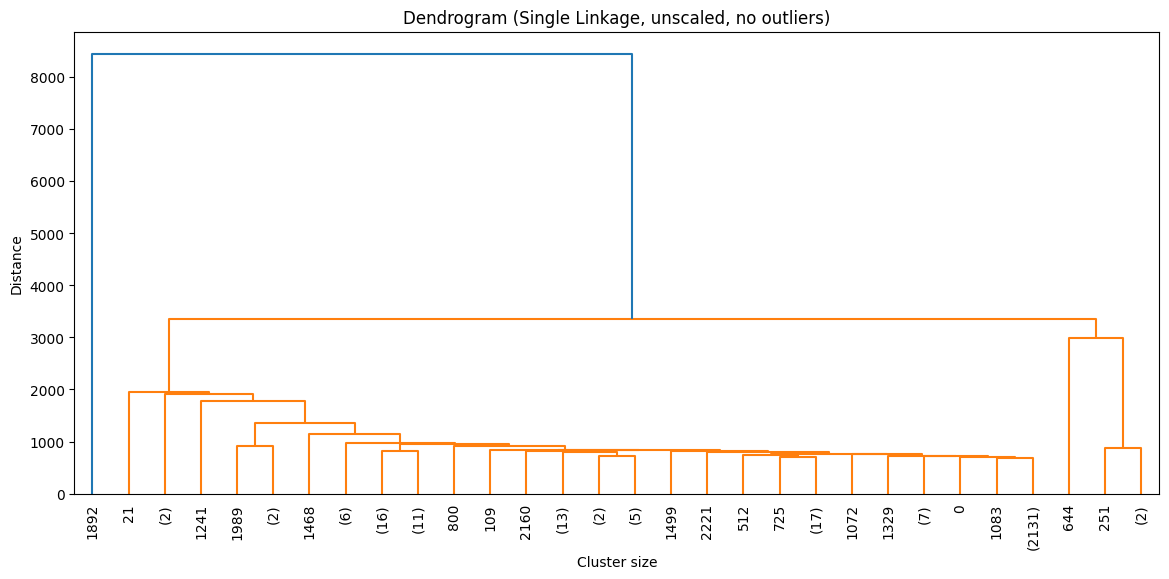

In [ ]:
# Невідмасштабовані дані з прибраними викидами (df_no_outliers) — використовуємо ті ж ознаки
X_hier = df_no_outliers[features].values

Z_single = linkage(X_hier, method='single')

plt.figure(figsize=(14, 6))
dendrogram(Z_single, truncate_mode='lastp', p=30, leaf_rotation=90)
plt.title('Dendrogram (Single Linkage, unscaled, no outliers)')
plt.xlabel('Cluster size')
plt.ylabel('Distance')
plt.show()

In [49]:
# Плоскі кластеризації з fcluster на 2 і 3 кластери
clusters_hier_2 = fcluster(Z_single, t=2, criterion='maxclust')
clusters_hier_3 = fcluster(Z_single, t=3, criterion='maxclust')

print("Розподіл по кластерах (2 кластери):")
print(pd.Series(clusters_hier_2).value_counts().sort_index())
print(f"\nРозподіл по кластерах (3 кластери):")
print(pd.Series(clusters_hier_3).value_counts().sort_index())

Розподіл по кластерах (2 кластери):
1    2231
2       1
Name: count, dtype: int64

Розподіл по кластерах (3 кластери):
1    2227
2       4
3       1
Name: count, dtype: int64


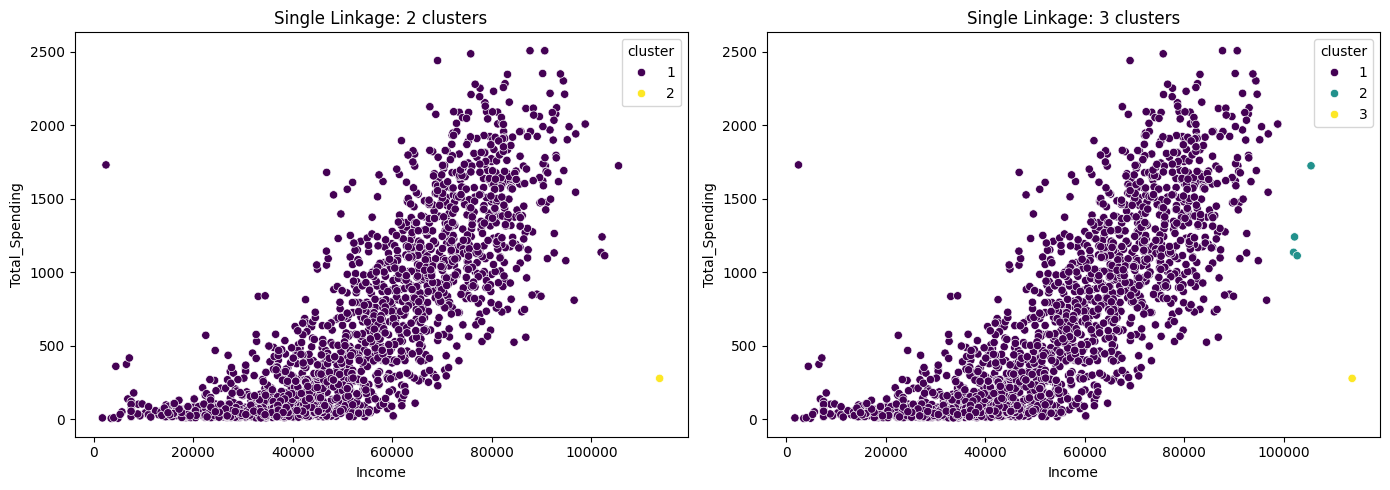

In [ ]:
# Візуалізація кластеризацій на 2 і 3 кластери
df_hier_viz = df_no_outliers[features].copy()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

df_hier_viz["cluster"] = clusters_hier_2
sns.scatterplot(
    data=df_hier_viz,
    x="Income",
    y="Total_Spending",
    hue="cluster",
    palette="viridis",
    ax=axes[0]
)
axes[0].set_title("Single Linkage: 2 clusters")

df_hier_viz["cluster"] = clusters_hier_3
sns.scatterplot(
    data=df_hier_viz,
    x="Income",
    y="Total_Spending",
    hue="cluster",
    palette="viridis",
    ax=axes[1]
)
axes[1].set_title("Single Linkage: 3 clusters")

plt.tight_layout()
plt.show()

In [51]:
score_hier_2 = silhouette_score(X_hier, clusters_hier_2)
score_hier_3 = silhouette_score(X_hier, clusters_hier_3)

print(f"Silhouette score (Single Linkage, 2 clusters): {score_hier_2:.4f}")
print(f"Silhouette score (Single Linkage, 3 clusters): {score_hier_3:.4f}")

Silhouette score (Single Linkage, 2 clusters): 0.5572
Silhouette score (Single Linkage, 3 clusters): 0.4503


Ієрархічна кластеризація з single linkage показала незадовільний результат. Більшість спостережень об’єднується в один великий кластер, тоді як окремі точки формують дуже малі кластери. Це пов’язано з ефектом chaining, характерним для single linkage, коли об’єкти послідовно з’єднуються через найближчих сусідів.

Хоча silhouette score для 2 кластерів є відносно високим (0.5572), такий поділ не має практичної цінності, оскільки фактично не виконується сегментація даних.

Отже, метод single linkage не підходить для цієї задачі, і KMeans дає значно більш інтерпретовані результати.

**Завдання 10.**
1. Використайте метод кластеризації, який ми не використовували в попередніх завданнях цього ДЗ (може бути ієрархічна кластеризація з іншим способом звʼязності або інші методи sklearn).
2. Порахуйте мер=трику силуету і візуалізуйте результат кластеризації. Зробіть висновок про те, чи могла б ця кластеризація бути корисною?

#### Ward linkage:

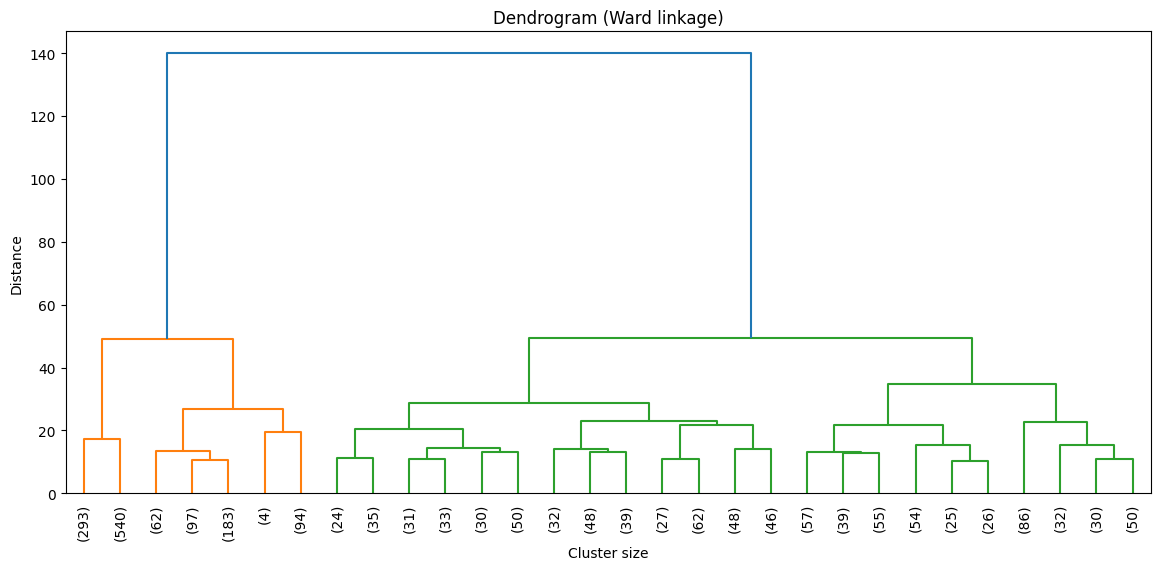

In [73]:
Z_ward = linkage(X_no_out, method="ward")

plt.figure(figsize=(14, 6))
dendrogram(
    Z_ward,
    truncate_mode="lastp",
    p=30,
    leaf_rotation=90,
    leaf_font_size=10
)
plt.title("Dendrogram (Ward linkage)")
plt.xlabel("Cluster size")
plt.ylabel("Distance")
plt.show()

In [75]:
# K=2
clusters_ward_2 = fcluster(Z_ward, t=2, criterion="maxclust")
score_war_2 = silhouette_score(X_no_out, clusters_ward_2)
print("Ward silhouette (K=2):", score_war_2)

# K=3
clusters_ward_3 = fcluster(Z_ward, t=3, criterion="maxclust")
score_war_3 = silhouette_score(X_no_out, clusters_ward_3)
print("Ward silhouette (K=3):", score_war_3)

Ward silhouette (K=2): 0.4557056143227667
Ward silhouette (K=3): 0.38005464793129673


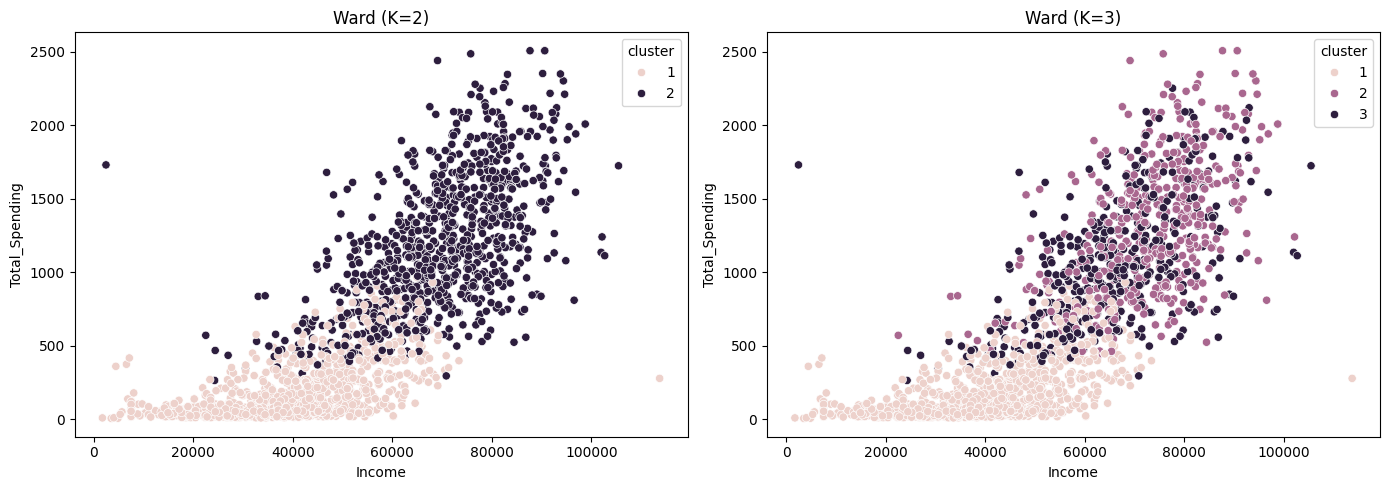

In [76]:
df_viz = df_no_outliers_clipped.copy()
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- K=2 ---
df_viz["cluster"] = clusters_ward_2
sns.scatterplot(
    data=df_viz,
    x="Income",
    y="Total_Spending",
    hue="cluster",
    ax=axes[0]
)
axes[0].set_title("Ward (K=2)")

# --- K=3 ---
df_viz["cluster"] = clusters_ward_3
sns.scatterplot(
    data=df_viz,
    x="Income",
    y="Total_Spending",
    hue="cluster",
    ax=axes[1]
)
axes[1].set_title("Ward (K=3)")

plt.tight_layout()
plt.show()

Для K=2 спостерігається чітке розділення клієнтів на дві групи з високим значенням silhouette score, однак така сегментація є занадто узагальненою.
Для K=3 з’являється більш детальний поділ на три сегменти (низький, середній і високий рівень витрат), проте межі між кластерами стають менш чіткими, що підтверджується нижчим значенням silhouette score.
Це свідчить про те, що дані мають скоріше безперервну структуру без різко виражених кластерів, тому вибір K залежить від задачі: K=2 — для простого поділу, K=3 — для більш детальної сегментації.

#### DBSCAN:

In [58]:
eps_values = [1.0, 1.1, 1.2, 1.5, 1.8, 2.0]

results = []

for eps in eps_values:
    dbscan = DBSCAN(eps=eps, min_samples=10)
    labels = dbscan.fit_predict(X_no_out)

    unique_labels = set(labels)
    n_clusters = len(unique_labels - {-1})
    n_noise = list(labels).count(-1)

    mask = labels != -1
    
    if n_clusters > 1:
        score = silhouette_score(X_no_out[mask], labels[mask])
    else:
        score = None

    results.append((eps, n_clusters, n_noise, score))

for eps, n_clusters, n_noise, score in results:
    print(f"eps={eps}: clusters={n_clusters}, noise={n_noise}, silhouette={score}")

eps=1.0: clusters=1, noise=933, silhouette=None
eps=1.1: clusters=2, noise=862, silhouette=0.49668131970957996
eps=1.2: clusters=8, noise=752, silhouette=0.34282530574482784
eps=1.5: clusters=2, noise=287, silhouette=0.22014112320978793
eps=1.8: clusters=1, noise=42, silhouette=None
eps=2.0: clusters=1, noise=13, silhouette=None


У цьому завданні було застосовано два різні підходи до кластеризації: ієрархічний метод Ward та алгоритм DBSCAN.

Метод Ward показав стабільну кластеризацію з silhouette ≈ 0.38 для K=3 та ≈ 0.46 для K=2. 

DBSCAN не продемонстрував стабільних результатів: при різних значеннях eps або значна частина даних визначається як шум, або всі точки об’єднуються в один кластер. Навіть при найкращому значенні (eps=1.1, silhouette ≈ 0.50) близько 40% об’єктів (862) віднесено до шуму, що робить результат практично непридатним для подальшого використання.

Загалом, результати свідчать про те, що дані мають безперервну (градієнтну) структуру без чітко виражених природних кластерів. У таких умовах метод Ward (як і KMeans) працює краще, оскільки дозволяє отримати керований і інтерпретований поділ даних.

Отже, для цього набору даних метод Ward є значно більш доцільним, ніж DBSCAN, а вибір кількості кластерів залежить від задачі: K=2 — для простого поділу, K=3 — для більш детальної сегментації клієнтів.